# Análisis Interactivo de Datos LiDAR del PNOA

Este notebook te permite explorar y procesar archivos LAZ del PNOA de forma interactiva.

In [1]:
# Importar librerías necesarias
import numpy as np
import laspy
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Explorar un archivo LAZ

In [2]:
# Especifica la ruta a tu archivo LAZ
archivo_laz = "ruta/a/tu/archivo.copc.laz"  # ← CAMBIA ESTO

# Leer el archivo
print(f"Leyendo: {archivo_laz}")
las = laspy.read(archivo_laz)

print(f"\n📊 Información básica:")
print(f"  - Total puntos: {len(las.points):,}")
print(f"  - Formato: LAS {las.header.version}")
print(f"  - Extensión X: {las.header.x_min:.2f} - {las.header.x_max:.2f} m")
print(f"  - Extensión Y: {las.header.y_min:.2f} - {las.header.y_max:.2f} m")
print(f"  - Extensión Z: {las.header.z_min:.2f} - {las.header.z_max:.2f} m")

Leyendo: /media/diego/Datos4/EBD/Tragsatec/Drones/Laz/las12/alcolea/PNOA_2024_AND_267-4166_H30_NPC01.copc.laz

📊 Información básica:
  - Total puntos: 9,830,220
  - Formato: LAS 1.4
  - Extensión X: 267000.00 - 268000.00 m
  - Extensión Y: 4165000.00 - 4166000.00 m
  - Extensión Z: 17.78 - 64.15 m


In [3]:
# Ver clasificaciones disponibles
clases_unicas = np.unique(las.classification)
print("\n🏷️ Clasificaciones disponibles:")

nombres = {
    0: "Nunca clasificado",
    1: "Sin clasificar",
    2: "Suelo",
    3: "Vegetación baja",
    4: "Vegetación media",
    5: "Vegetación alta",
    6: "Edificio",
    9: "Agua"
}

for clase in sorted(clases_unicas):
    count = np.sum(las.classification == clase)
    porcentaje = (count / len(las.points)) * 100
    nombre = nombres.get(clase, f"Desconocida")
    print(f"  Clase {clase}: {nombre} - {count:,} puntos ({porcentaje:.1f}%)")


🏷️ Clasificaciones disponibles:
  Clase 1: Sin clasificar - 143,909 puntos (1.5%)
  Clase 2: Suelo - 3,524,674 puntos (35.9%)
  Clase 3: Vegetación baja - 452,831 puntos (4.6%)
  Clase 4: Vegetación media - 1,193,993 puntos (12.1%)
  Clase 5: Vegetación alta - 1,260,978 puntos (12.8%)
  Clase 6: Edificio - 14,580 puntos (0.1%)
  Clase 7: Desconocida - 218 puntos (0.0%)
  Clase 12: Desconocida - 3,239,037 puntos (32.9%)


## 2. Visualización 3D (muestra aleatoria)

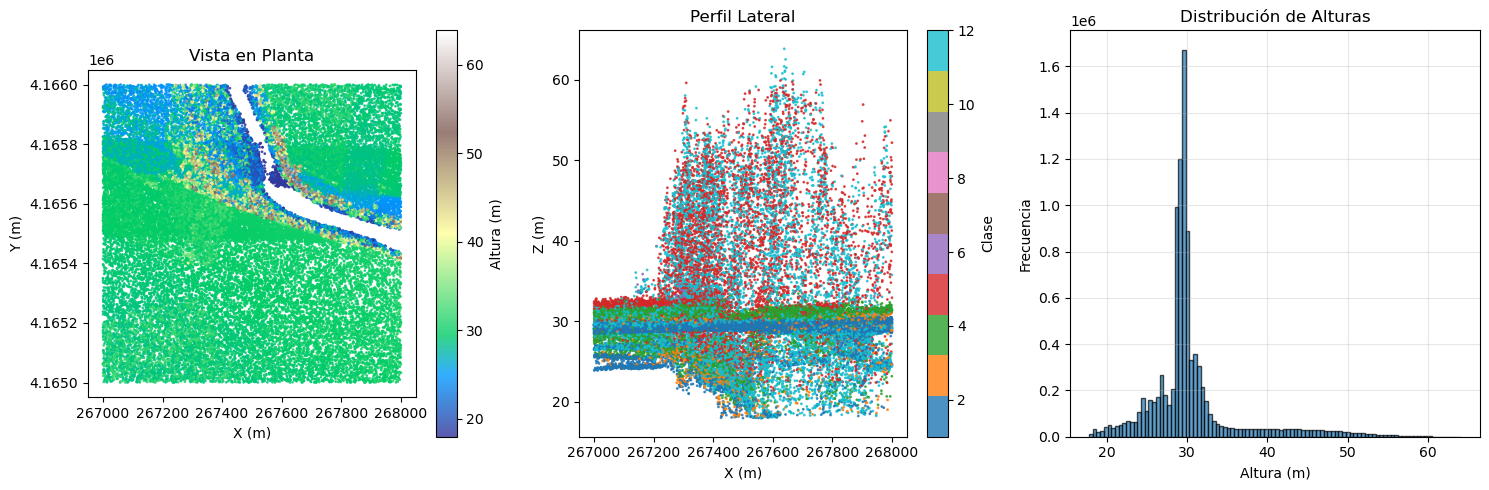

In [4]:
# Tomar una muestra aleatoria para visualizar (para no saturar la memoria)
n_muestra = min(50000, len(las.points))
indices = np.random.choice(len(las.points), n_muestra, replace=False)

fig = plt.figure(figsize=(15, 5))

# Vista en planta (XY) coloreado por altura
ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(las.x[indices], las.y[indices], c=las.z[indices], 
                       s=1, cmap='terrain', alpha=0.8)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('Vista en Planta')
ax1.set_aspect('equal')
plt.colorbar(scatter1, ax=ax1, label='Altura (m)')

# Vista lateral (XZ) coloreado por clasificación
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(las.x[indices], las.z[indices], c=las.classification[indices],
                       s=1, cmap='tab10', alpha=0.8)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_title('Perfil Lateral')
plt.colorbar(scatter2, ax=ax2, label='Clase')

# Histograma de alturas
ax3 = fig.add_subplot(133)
ax3.hist(las.z, bins=100, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Altura (m)')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Alturas')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Filtrar puntos por clase

In [5]:
# Extraer solo puntos de suelo (clase 2)
mask_suelo = las.classification == 2
x_suelo = las.x[mask_suelo]
y_suelo = las.y[mask_suelo]
z_suelo = las.z[mask_suelo]

print(f"Puntos de suelo: {len(x_suelo):,} ({len(x_suelo)/len(las.points)*100:.1f}%)")

# Extraer vegetación (clases 3, 4, 5)
mask_veg = np.isin(las.classification, [3, 4, 5])
x_veg = las.x[mask_veg]
y_veg = las.y[mask_veg]
z_veg = las.z[mask_veg]

print(f"Puntos de vegetación: {len(x_veg):,} ({len(x_veg)/len(las.points)*100:.1f}%)")

Puntos de suelo: 3,524,674 (35.9%)
Puntos de vegetación: 2,907,802 (29.6%)


# Mosaicado de nubes de puntos en un solo archivo

In [28]:
import laspy
import numpy as np
from pathlib import Path

carpeta = Path("ruta/a/tus/tiles/")
archivos = sorted(carpeta.glob("*.copc.laz"))
print(f"Tiles encontrados: {len(archivos)}")

# Leer todos los tiles
las_list = []
for archivo in archivos:
    print(f"Leyendo {archivo.name}...")
    las_list.append(laspy.read(archivo))

print(f"Total puntos: {sum(len(l.points) for l in las_list):,}")

# Concatenar usando laspy directamente
#print("Concatenando...")
#las_merged = laspy.concatenate(las_list)

# Guardar
salida = "ruta/a/tus/tiles//merged_11tiles.laz"

header_nuevo = laspy.LasHeader(
    point_format=las_list[0].header.point_format,
    version=las_list[0].header.version
)
header_nuevo.offsets = las_list[0].header.offsets
header_nuevo.scales = las_list[0].header.scales

print("Guardando...")
with open(salida, "wb") as f:
    with laspy.LasWriter(f, header=header_nuevo) as writer:
        for i, las in enumerate(las_list):
            print(f"  Escribiendo tile {i+1}/11...")
            writer.write_points(las.points)

print("Guardado.")

Tiles encontrados: 11
Leyendo PNOA_2024_AND_267-4166_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_267-4167_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_267-4168_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_267-4169_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_268-4166_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_268-4167_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_268-4168_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_268-4169_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_269-4167_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_269-4168_H30_NPC01.copc.laz...
Leyendo PNOA_2024_AND_269-4169_H30_NPC01.copc.laz...
Total puntos: 113,816,704
Guardando...
  Escribiendo tile 1/11...
  Escribiendo tile 2/11...
  Escribiendo tile 3/11...
  Escribiendo tile 4/11...
  Escribiendo tile 5/11...
  Escribiendo tile 6/11...
  Escribiendo tile 7/11...
  Escribiendo tile 8/11...
  Escribiendo tile 9/11...
  Escribiendo tile 10/11...
  Escribiendo tile 11/11...
Guardado.


In [24]:
print(laspy.__version__)
print([x for x in dir(laspy) if not x.startswith('_')])

2.6.1
['Bounds', 'CopcReader', 'DecompressionSelection', 'DimensionInfo', 'DimensionKind', 'ExtraBytesParams', 'LasData', 'LasHeader', 'LasReader', 'LasWriter', 'LaspyException', 'LazBackend', 'PackedPointRecord', 'PointFormat', 'ScaleAwarePointRecord', 'VLR', 'compression', 'convert', 'copc', 'create', 'errors', 'extradims', 'file', 'header', 'lasappender', 'lasdata', 'lasmmap', 'lasreader', 'laswriter', 'lib', 'logging', 'lost_dimensions', 'mmap', 'open', 'point', 'read', 'supported_point_formats', 'supported_versions', 'typehints', 'utils', 'vlrs']


## 5. Generar DSM (Digital Surface Model)

In [30]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
from scipy.ndimage import distance_transform_edt
import laspy

print("Leyendo merged...")
las_merged = laspy.read("ruta/a/tus/tiles//merged_11tiles.laz")

x_all = np.asarray(las_merged.x, dtype=np.float64)
y_all = np.asarray(las_merged.y, dtype=np.float64)
z_all = np.asarray(las_merged.z, dtype=np.float64)
clases = np.asarray(las_merged.classification)

print(f"Total puntos: {len(x_all):,}")

# ---- PARÁMETROS ----
resolucion = 0.5
ruta_salida = "ruta/de/salida/"

# ---- DEFINIR GRID ----
x_min, x_max = x_all.min(), x_all.max()
y_min, y_max = y_all.min(), y_all.max()

cols = int((x_max - x_min) / resolucion) + 1
rows = int((y_max - y_min) / resolucion) + 1
transform = from_origin(x_min, y_max, resolucion, resolucion)

print(f"Grid: {rows} filas x {cols} columnas")
print(f"Total puntos: {len(z_all):,}")

# ---- FUNCIÓN DE RELLENO ----
def rellenar_huecos(array):
    mask = np.isnan(array)
    if mask.any():
        idx = distance_transform_edt(mask, return_distances=False, return_indices=True)
        return array[tuple(idx)]
    return array

# ---- FUNCIÓN DE GUARDADO ----
def guardar_tif(array, nombre):
    ruta = ruta_salida + nombre
    with rasterio.open(ruta, "w", driver="GTiff",
                       height=rows, width=cols, count=1, dtype="float32",
                       crs="EPSG:25830", transform=transform, nodata=np.nan) as dst:
        dst.write(array.astype(np.float32), 1)
    print(f"Guardado: {ruta}  Min: {array.min():.2f}  Max: {array.max():.2f}")

# ---- FUNCIÓN DE BINNING ----
def calcular_raster(x, y, z, operacion='min'):
    col_idx = np.floor((x - x_min) / resolucion).astype(np.int32).clip(0, cols - 1)
    row_idx = np.floor((y_max - y) / resolucion).astype(np.int32).clip(0, rows - 1)
    df = pd.DataFrame({'row': row_idx, 'col': col_idx, 'z': z})
    if operacion == 'min':
        resultado = df.groupby(['row', 'col'])['z'].min()
    else:
        resultado = df.groupby(['row', 'col'])['z'].max()
    raster = np.full((rows, cols), np.nan, dtype=np.float32)
    raster[resultado.index.get_level_values('row'),
           resultado.index.get_level_values('col')] = resultado.values.astype(np.float32)
    return raster

# ---- DTM ----
print("\nGenerando DTM...")
mask_suelo = clases == 2
x_suelo = x_all[mask_suelo]
y_suelo = y_all[mask_suelo]
z_suelo = z_all[mask_suelo]
print(f"Puntos de suelo: {len(z_suelo):,}")

dtm = calcular_raster(x_suelo, y_suelo, z_suelo, operacion='min')
print(f"Huecos DTM: {np.isnan(dtm).sum():,} ({100*np.isnan(dtm).mean():.1f}%)")
dtm_filled = rellenar_huecos(dtm)
guardar_tif(dtm_filled, "dtm_05.tif")

# ---- DSM ----
print("\nGenerando DSM...")
mask_dsm = ~np.isin(clases, [7, 12])
x_dsm = x_all[mask_dsm]
y_dsm = y_all[mask_dsm]
z_dsm = z_all[mask_dsm]
print(f"Puntos para DSM: {len(z_dsm):,}")

dsm = calcular_raster(x_dsm, y_dsm, z_dsm, operacion='max')
print(f"Huecos DSM: {np.isnan(dsm).sum():,} ({100*np.isnan(dsm).mean():.1f}%)")
dsm_filled = rellenar_huecos(dsm)
guardar_tif(dsm_filled, "dsm_05.tif")

# ---- CHM ----
print("\nGenerando CHM...")
chm = dsm_filled - dtm_filled
chm[chm < 0] = 0
guardar_tif(chm, "chm_05.tif")

print("\nProceso completado.")

Leyendo merged...
Total puntos: 113,816,704
Grid: 8000 filas x 6000 columnas
Total puntos: 113,816,704

Generando DTM...
Puntos de suelo: 40,815,771
Huecos DTM: 19,527,484 (40.7%)
Guardado: /home/diego/dtm_05.tif  Min: 17.64  Max: 120.35

Generando DSM...
Puntos para DSM: 70,948,102
Huecos DSM: 7,978,592 (16.6%)
Guardado: /home/diego/dsm_05.tif  Min: 17.71  Max: 145.65

Generando CHM...
Guardado: /home/diego/chm_05.tif  Min: 0.00  Max: 51.54

Proceso completado.
